# Tutorial 4: Cross-platform denoising and integration of MOB datasets

In this tutorial, we evaluate the robustness and generalizability of STADIM across different spatial capture technologies. We analyzed a mouse olfactory bulb (MOB) dataset with subcellular resolution from Stereo-seq and Slide-seq V2 platforms.  
Stereo-seq dataset was accessed via GitHub https://github.com/JinmiaoChenLab/SEDR_analyses/blob/master/data/Stero-seq.tar.gz, while the Slide-seq V2 data were retrieved from the Broad Institute Single Cell Portal under study SCP815 https://singlecell.broadinstitute.org/single_cell/study/SCP815.

## Quick view data

In [1]:
import anndata as ad
import os

sample_ids = ['MOB_slideseq', 'MOB_stereoseq']
data_dir = '/data2/xiaost/SODA/Data/MOB/'

for i, s_id in enumerate(sample_ids):
    adata = ad.read_h5ad(os.path.join(data_dir, f'{s_id}.h5ad'))
    print(f'{s_id}')
    print(adata)

MOB_slideseq
AnnData object with n_obs × n_vars = 20139 × 21220
    obs: 'xcoord', 'ycoord', 'array_col', 'array_row', 'sample'
    obsm: 'spatial'
MOB_stereoseq
AnnData object with n_obs × n_vars = 19109 × 27106
    obs: 'x', 'y', 'array_col', 'array_row', 'sample'
    obsm: 'spatial'


## Run STADIM

**Note: For the high-resolution dataset, we added filtering criteria to the cells and selected more candidate neighbors during the triplet construction phase.**

You can call the STADIM command directly in your terminal:
```bash
nohup stadim --input "./MOB_slideseq.h5ad" "./MOB_stereoseq.h5ad" --save_preprocessed_h5ad None --save_dir ./MOB_test --device "cuda:0" --monitor --seed 2026 --min_genes 10 --min_cells 10 --knn_c 30 --knn_e 70 --mnn_n 100 > ./MOB_test.log 2>&1 &
```
and load the results into your Python environment for downstream analysis. The denoised expression matrix is conveniently stored within the `layers` attribute:
```python
import anndata as ad

adata = ad.read_h5ad('/MOB_test/sdata.h5ad')

## The denoised gene expressionis is stored in adata.layers['STADIM']
print(adata)
```
or you can call STADIM within a Jupyter Notebook as follows:

In [2]:
import stadim

adata = stadim.run_STADIM(['/data2/xiaost/SODA/Data/MOB/MOB_slideseq.h5ad', '/data2/xiaost/SODA/Data/MOB/MOB_stereoseq.h5ad'], 
                          save_preprocessed_h5ad=None, save_dir=None, 
                          sample_names=None, batch_key='sample', device='cuda:4', seed=2026, 
                          min_genes=10, min_cells=10, nhvgs=2000, dim=50, knn_c=30, knn_e=70, mnn_n=100,
                          batch_size=256, triplets_update_ratio=0.8, hard_triplets_ratio=0.7,
                          epochs=100, lr=1e-3, loss_mode='nb', beta_trip=0.1,
                          encoder_layers=[512, 256, 64], decoder_layers=[1000])

Results will be stored in adata.layers['STADIM']

=== 1. Begin read_data!
Detected multi-slice data, total 2 slices
  Slice 1: Using user-defined column 'sample' as sample
  Slice 1: Keeping existing sample label MOB_slideseq
  Slice 2: Using user-defined column 'sample' as sample
  Slice 2: Keeping existing sample label MOB_stereoseq

Merging data...

Raw Merged Data: 39248 spots × 30047 genes
Unified Filtering (min_genes=10, min_cells=10)...
  → After Filtering: 39248 spots × 22163 genes
  ✓ Complete: Samples included: ['MOB_slideseq', 'MOB_stereoseq']
  ✓ Complete: AnnData object with n_obs × n_vars = 39248 × 22163
    obs: 'xcoord', 'ycoord', 'array_col', 'array_row', 'sample', 'x', 'y', 'n_genes'
    var: 'n_cells'
    obsm: 'spatial'
    layers: 'X_raw'

=== 2. Begin MY_preprocess!
== Selected 2000 HVGs across 2 slices

=== 3. Begin all_ap find neighbors!

=== 4. Begin pre_dataset!
{0: 'MOB_slideseq', 1: 'MOB_stereoseq'}


Preparing triplet: 100%|██████████| 39248/39248 [00:16<00:00, 2416.48it/s]



=== 5. Begin IterableTripletDataset!
Initializing triplets...
IterableTripletDataset Initialized: 39248 anchors, batch_size=256

=== 6. Begin calculate_recommended_margin!
Calculating recommended margin (averaging over 5 runs)...

Margins from 5 runs: [5.0218, 5.0555, 5.0051, 5.2689, 5.0979]
Final Recommended Margin: 5.0898

=== 7. Starting training...
Begin training: device=cuda:4


Training: 100%|██████████| 100/100 [16:42<00:00, 10.03s/it, recon=0.059, triplet=0.907, total=0.149]



=== 8. Generating denoised expression...
   Data size (8.70e+08) is within limits. Allocating memory for denoised data.

All processes finished! Total time: 19.48 mins.


In [3]:
print(adata)

AnnData object with n_obs × n_vars = 39248 × 22163
    obs: 'xcoord', 'ycoord', 'array_col', 'array_row', 'sample', 'x', 'y', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'size_factor'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable'
    uns: 'log1p', 'top_hvgs'
    obsm: 'spatial', 'S_scale', 'X_hvg_scale', 'X_pca', 'cell_names', 'STADIM'
    layers: 'X_raw', 'X_norm', 'X_log', 'STADIM', 'STADIM_withbatch'


## Analysis

In [4]:
import anndata as ad
import pandas as pd
import scanpy as sc 
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
plt.rcParams.update({
    'font.size': 16, 
    'axes.labelsize': 18,  
    'axes.titlesize': 18,  
    'xtick.labelsize': 16, 
    'ytick.labelsize': 16,  
    'legend.fontsize': 16,
})

my_colors = ['#ff9896','#8c564b', '#17becf','#2ca02c','#1f77b4','#6a3d9a','#d62728', '#dbdb8d', "#9b2626", '#ff7f0e']

### Louvain

The following package needs to be installed in the environment:
```bash
pip install louvain python-igraph
```

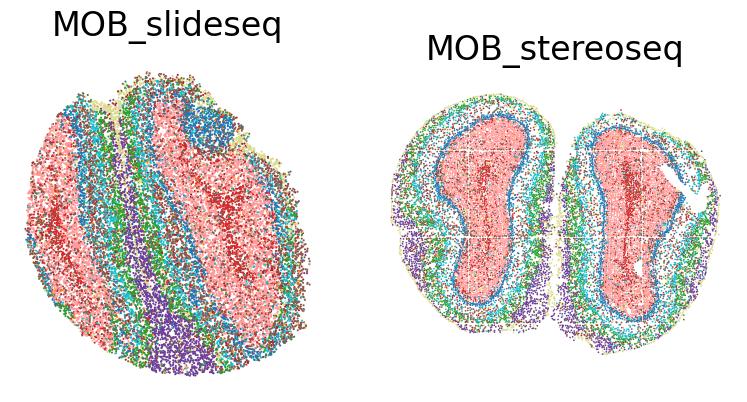

In [9]:
method = 'STADIM'
cluster_key = f"{method}_clusters"

sc.pp.neighbors(adata, use_rep=method, key_added=method)
sc.tl.louvain(adata, neighbors_key=method, key_added=cluster_key, resolution=0.5)
n_clusters = len(adata.obs[cluster_key].unique())
# print(n_clusters)
adata.uns[f"{cluster_key}_colors"] = my_colors[:n_clusters]

# if n_clusters==nnn:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for i, sample_id in enumerate(sample_ids):
    ax = axes[i]
    sub_adata = adata[adata.obs['sample'] == sample_id]
    sc.pl.spatial(sub_adata, color=cluster_key, spot_size=30, title=None, show=False, ax=ax, legend_loc=None)
    ax.set_title(sample_id, fontsize=24, pad=15)#, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_aspect('equal') 
    ax.axis('off')
    
plt.tight_layout()
plt.subplots_adjust(hspace=0.05, top=0.9)
plt.show()

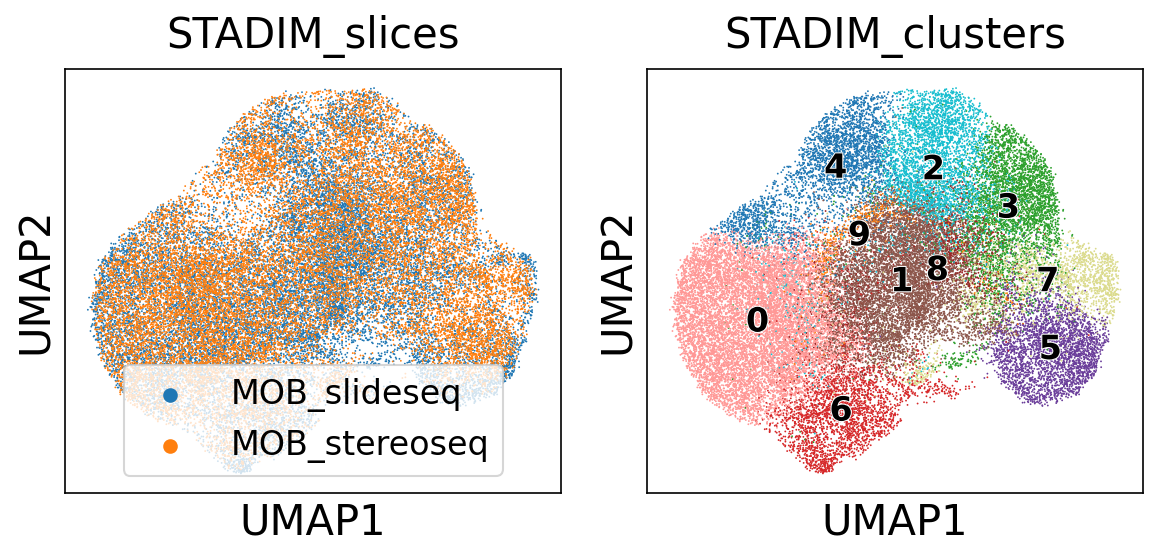

In [10]:
# cluster_key = f"{method}_clusters"
umap_key = f"X_umap_{method}"

sc.tl.umap(adata, neighbors_key=method)
adata.obsm[umap_key] = adata.obsm['X_umap'].copy()

fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=150)
sc.pl.embedding(adata, basis=umap_key, color='sample', 
                palette=["#1F77B4FF", "#FF7F0EFF"], 
                legend_loc='lower center', ax=axes[0], show=False)
axes[0].set_title(f"{method}_slices", fontsize=20, pad=10)

sc.pl.embedding(adata, basis=umap_key, color=cluster_key, 
                legend_loc='on data', legend_fontsize=16, legend_fontweight='bold', legend_fontoutline=1,
                ax=axes[1], show=False)
axes[1].set_title(f"{method}_clusters", fontsize=20, pad=10)

for ax in axes:
    ax.set_xlabel("UMAP1", fontsize=20)
    ax.set_ylabel("UMAP2", fontsize=20)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()